In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

In [2]:
df = pd.read_csv("../data/cleaned/telco_cleaned.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df_ml = df.copy()

encoder = LabelEncoder()

for column in df_ml.columns:
    if df_ml[column].dtype == "object":
        df_ml[column] = encoder.fit_transform(df_ml[column])

In [4]:
df_ml.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,5365,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,29.85,0
1,3953,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1889.50,0
2,2558,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,108.15,1
3,5524,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1840.75,0
4,6500,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,151.65,1


In [5]:
X = df_ml.drop("Churn", axis=1)

y = df_ml["Churn"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

/Users/raj/Downloads/customer-churn-analytics/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [8]:
pred_lr = lr.predict(X_test)

In [9]:
print("Accuracy:", accuracy_score(y_test, pred_lr))

Accuracy: 0.7882018479033405


In [10]:
print(classification_report(y_test, pred_lr))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [11]:
print(classification_report(y_test, pred_lr))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [12]:
print(confusion_matrix(y_test, pred_lr))

[[920 113]
 [185 189]]


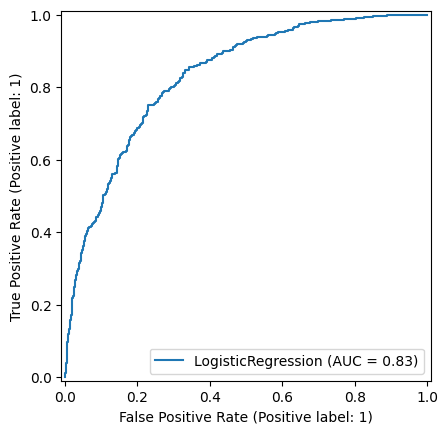

In [13]:
RocCurveDisplay.from_estimator(lr, X_test, y_test)

plt.show()

In [14]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [15]:
pred_rf = rf.predict(X_test)

In [16]:
print("Accuracy:", accuracy_score(y_test, pred_rf))

Accuracy: 0.7924662402274343


In [17]:
print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.65      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [18]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
19,TotalCharges,0.152680
18,MonthlyCharges,0.149295
5,tenure,0.136959
0,customerID,0.126861
15,Contract,0.080929
9,OnlineSecurity,0.045474
17,PaymentMethod,0.043532
12,TechSupport,0.040157
8,InternetService,0.024154
10,OnlineBackup,0.023744


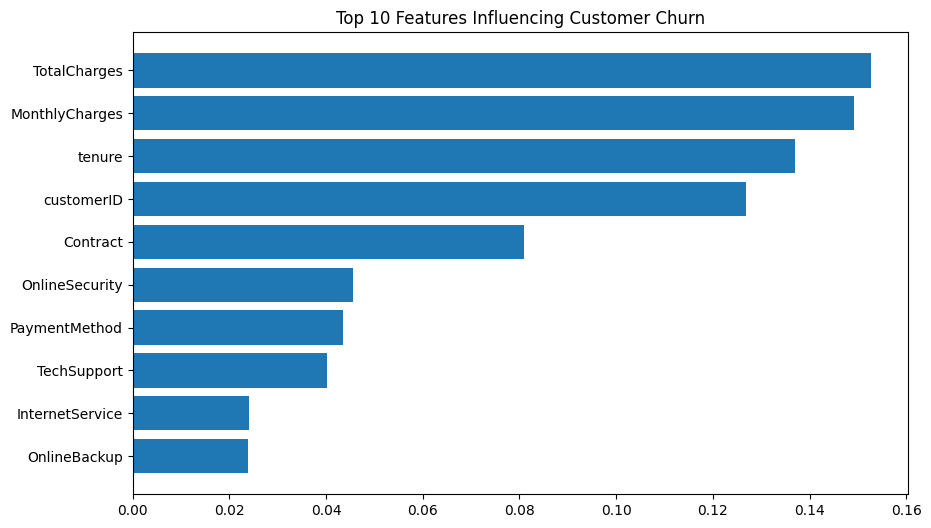

In [19]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:10],
    importance["Importance"][:10]
)

plt.title("Top 10 Features Influencing Customer Churn")

plt.gca().invert_yaxis()

plt.show()

In [20]:
## Business Findings

#The Random Forest model identified the following key drivers of customer churn:

#- Contract type
#- Tenure
#- Monthly charges
#- Total charges
#- Internet service

#These findings suggest that customers on short-term contracts with higher monthly charges are at greater risk of leaving. The business can use this information to design targeted retention campaigns and improve customer lifetime value.